# Playing with Shapley Values

In [ ]:
from pathlib import Path

OUT_DIR = Path("out")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def out_path(filename):
    return OUT_DIR / filename


In [ ]:
import json
import math
import sys
from itertools import combinations, permutations
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import shap
import torch
from matplotlib.colors import ListedColormap
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from torchvision import models

ROOT = Path.cwd()
while not (ROOT / "xai_book").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from xai_book.plotting import BLUE as bookBlue, CHAPTER_GRAY as chaptergray, ORANGE as bookOrange, apply_notebook_style

apply_notebook_style()

data = fetch_california_housing()
X, y = data.data, data.target
feature_names = data.feature_names
df = pd.DataFrame(X, columns=feature_names)
X_train_df, X_test_df, y_train, y_test = train_test_split(
    df, y, test_size=0.2, random_state=0
)

X_train = X_train_df.values
X_test = X_test_df.values

model_full = LinearRegression().fit(X_train, y_train)


## 1. Shapley Regression Values Visualization

This notebook computes exact Shapley regression values for a linear regression model on the California housing dataset and visualizes them with positive contributions in **orange**, negative contributions in **blue**, and labels in **chapter gray**.


In [ ]:
# Shapley computation
def compute_shapley(model_class, X_train, y_train, x_instance):
    D = X_train.shape[1]
    shapley = np.zeros(D)
    baseline = np.mean(y_train)
    total_fact = math.factorial(D)
    for i in range(D):
        phi = 0
        others = [j for j in range(D) if j != i]
        for k in range(D):
            for S in combinations(others, k):
                S = list(S)
                coeff = (
                    math.factorial(len(S))
                    * math.factorial(D - len(S) - 1)
                    / total_fact
                )
                if S:
                    f_S = model_class().fit(X_train[:, S], y_train).predict(
                        x_instance[S].reshape(1, -1)
                    )[0]
                else:
                    f_S = baseline
                Si = S + [i]
                f_Si = model_class().fit(X_train[:, Si], y_train).predict(
                    x_instance[Si].reshape(1, -1)
                )[0]
                phi += coeff * (f_Si - f_S)
        shapley[i] = phi
    return shapley

x0 = X_test[0]
shap_vals = compute_shapley(LinearRegression, X_train, y_train, x0)

df = pd.DataFrame({'Feature': feature_names, 'Shapley Value': shap_vals})
df['Sign'] = df['Shapley Value'].apply(lambda value: 'Positive' if value >= 0 else 'Negative')

fig = px.bar(
    df,
    x='Feature',
    y='Shapley Value',
    color='Sign',
    color_discrete_map={'Positive': bookOrange, 'Negative': bookBlue},
    template='plotly_white',
    title='Shapley Regression Values for First Test Instance',
)

fig.update_layout(
    title_font_color=chaptergray,
    xaxis_title_font_color=chaptergray,
    yaxis_title_font_color=chaptergray,
    legend_title_font_color=chaptergray,
    font=dict(color=chaptergray),
    xaxis_tickangle=45,
)

fig.show()
fig.write_image(
    str(out_path('shapley_regression_plot.pdf')),
    format='pdf',
    width=800,
    height=600,
)


## 2. Shapley Sampling Values

We train a linear regression on the California housing dataset and estimate Shapley values for the first test instance by sampling permutations and using conditional expectation via data sampling.

Positive contributions are shown in **orange**, negative contributions in **blue**, and the textual framing uses **chapter gray**.


In [36]:
def sample_conditional_expectation(model, x_instance, S, X_reference, num_samples=50):
    """Estimate E[f(x) | x_S = x_instance_S] by sampling."""
    D = X_reference.shape[1]
    others = [i for i in range(D) if i not in S]
    idx = np.random.choice(X_reference.shape[0], size=num_samples, replace=True)
    X_sample = X_reference[idx]
    preds = []
    for row in X_sample:
        x_mod = np.array(x_instance, copy=True)
        for j in others:
            x_mod[j] = row[j]
        preds.append(model.predict(x_mod.reshape(1, -1))[0])
    return np.mean(preds)

def shapley_sampling(model, x_instance, X_reference, M=200, K=50):
    """Approximate Shapley values via sampling M permutations and K conditional samples."""
    D = X_reference.shape[1]
    shapley_vals = np.zeros(D)
    perms = [np.random.permutation(D) for _ in range(M)]
    for perm in perms:
        for j in range(D):
            idx_j = np.where(perm == j)[0][0]
            S = list(perm[:idx_j])
            f_S = sample_conditional_expectation(model, x_instance, S, X_reference, num_samples=K)
            f_Sj = sample_conditional_expectation(model, x_instance, S + [j], X_reference, num_samples=K)
            shapley_vals[j] += (f_Sj - f_S)
    return shapley_vals / M

In [ ]:
# Compute approximate Shapley sampling values and plot
shap_vals_sampling = shapley_sampling(model_full, x0, X_train, M=200, K=50)

df = pd.DataFrame({'Feature': feature_names, 'Shapley Value': shap_vals_sampling})
df['Sign'] = df['Shapley Value'].apply(lambda value: 'Positive' if value >= 0 else 'Negative')

fig = px.bar(
    df,
    x='Feature',
    y='Shapley Value',
    color='Sign',
    color_discrete_map={'Positive': bookOrange, 'Negative': bookBlue},
    template='plotly_white',
    title='Shapley Sampling Values',
)
fig.update_layout(
    title_font_color=chaptergray,
    xaxis_title_font_color=chaptergray,
    yaxis_title_font_color=chaptergray,
    font=dict(color=chaptergray),
    xaxis_tickangle=45,
)
fig.show()
fig.write_image(
    str(out_path('shapley_sampling_plot.pdf')),
    format='pdf',
    width=800,
    height=600,
)


## 3. Kernel SHAP Explanation

Example of Kernel SHAP applied to a linear regression model on the California housing dataset. Positive contributions are shown in **orange**, negative contributions in **blue**, and the Plotly labels use **chapter gray**.


In [38]:
shap.initjs()
# 1. create a small background sample for Kernel SHAP
bg = shap.sample(X_train, 100, random_state=0)

# 2. fit explainer
explainer = shap.Explainer(model_full, X_train)

shap_values = explainer(X_test_df)


In [ ]:
shap_vals_arr = shap_values.values[0]

df_shap = pd.DataFrame({'Feature': feature_names, 'SHAP Value': shap_vals_arr})
df_shap['Sign'] = np.where(df_shap['SHAP Value'] >= 0, 'Positive', 'Negative')

fig = px.bar(
    df_shap,
    x='Feature',
    y='SHAP Value',
    color='Sign',
    color_discrete_map={'Positive': bookOrange, 'Negative': bookBlue},
    template='plotly_white',
    title='Kernel SHAP Values for First Test Instance',
)
fig.update_layout(
    title_font_color=chaptergray,
    xaxis_title_font_color=chaptergray,
    yaxis_title_font_color=chaptergray,
    font=dict(color=chaptergray),
    xaxis_tickangle=45,
)
fig.show()

fig.write_image(
    str(out_path('kernel_shap_california.pdf')),
    format='pdf',
    width=800,
    height=600,
)


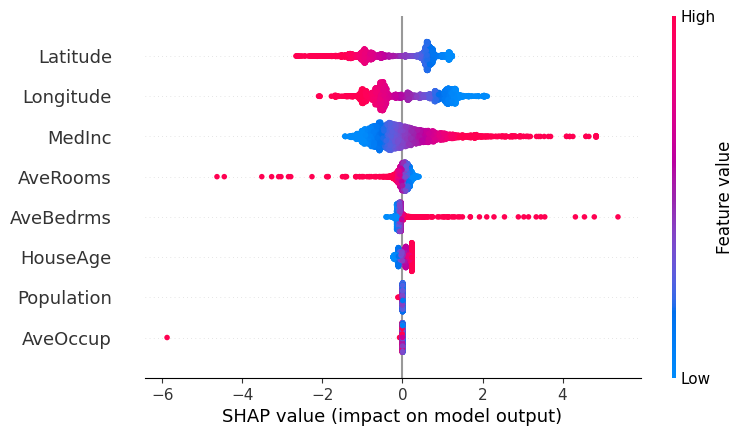

In [40]:
import shap
import matplotlib.pyplot as plt

# Assuming you have `shap_values` defined.
# If not, you'll need to calculate them first using a SHAP explainer.
# Example:
# explainer = shap.TreeExplainer(model)
# shap_values = explainer.shap_values(X)

shap.plots.beeswarm(shap_values, max_display=10, show=False)
plt.savefig(out_path("beeswarm_plot.pdf"), bbox_inches='tight')
plt.show()


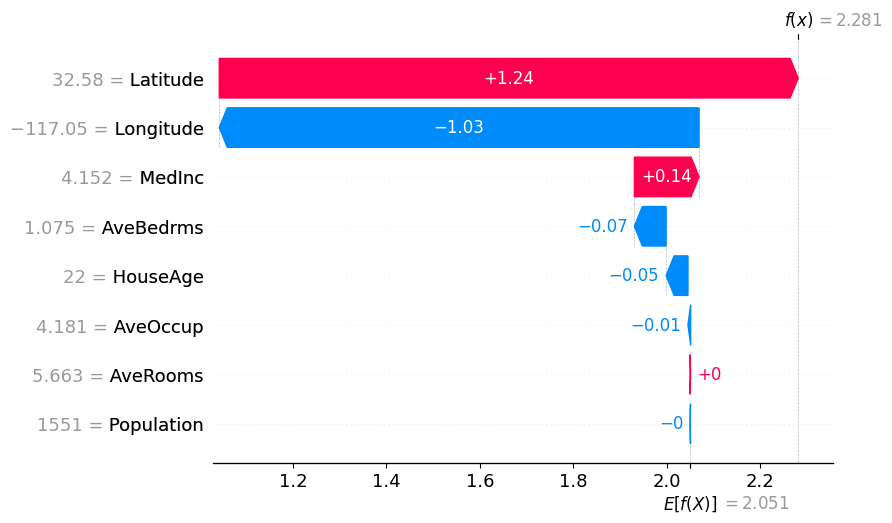

In [41]:
# Local explanation: waterfall plot for first test instance (index 0)
shap.plots.waterfall(shap_values[0], max_display=10)

### Explain an Intermediate Layer of VGG16 on ImageNet (PyTorch)
Note, this code is heavily adapted from the officail shap Github : https://github.com/shap/shap/blob/master/notebooks/image_examples/image_classification/Explain%20an%20Intermediate%20Layer%20of%20VGG16%20on%20ImageNet%20(PyTorch).ipynb  

Explaining a prediction in terms of the original input image is harder than explaining the predicition in terms of a higher convolutional layer (because the higher convolutional layer is closer to the output). This notebook gives a simple example of how to use GradientExplainer to do explain a model output with respect to the 7th layer of the pretrained VGG16 network.
Note that by default 200 samples are taken to compute the expectation. To run faster you can lower the number of samples per explanation.

In [42]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]


def normalize(image):
    if image.max() > 1:
        image /= 255
    image = (image - mean) / std
    # in addition, roll the axis so that they suit pytorch
    return torch.tensor(image.swapaxes(-1, 1).swapaxes(2, 3)).float()


--- Model's Top 2 Predictions and Plot Labels ---
For image 0:
  Rank 1: Class ID 142 (dowitcher), Probability: 0.9868
  Rank 2: Class ID 141 (redshank), Probability: 0.0125
For image 1:
  Rank 1: Class ID 299 (meerkat), Probability: 0.5813
  Rank 2: Class ID 298 (mongoose), Probability: 0.2021

--- SHAP Explainer's Returned Indexes (for verification) ---
[[142 141]
 [299 298]]


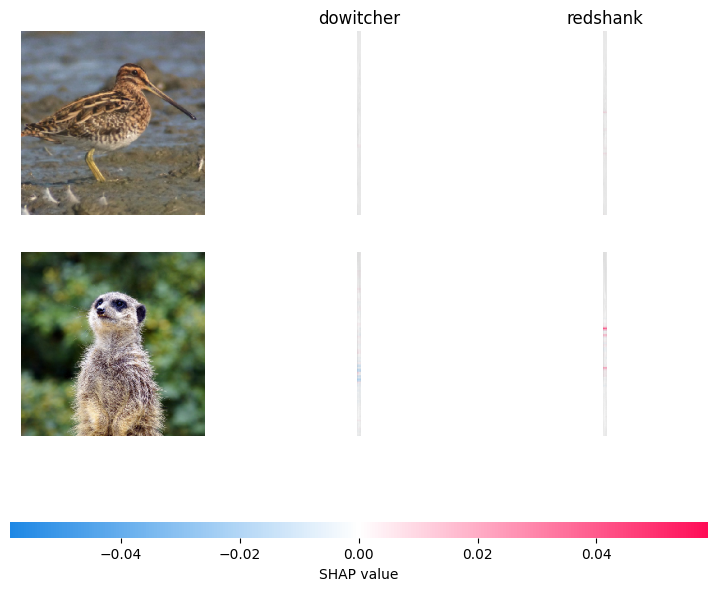

Saved to: /Users/juliawenkmann/Documents/CodingProjects/explainable-ai-supplementary-material/Figures/03_Perturbation_Based/shap/shap_image_plot_fixed_labels_final.pdf


<Figure size 640x480 with 0 Axes>

In [43]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import shap
import torch
from torchvision import models
from torchvision.models import VGG16_Weights # Import VGG16_Weights

# 1) load the model with the updated weights argument
model = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1).eval()

# 2) get 50 Imagenet samples & normalize
X, y = shap.datasets.imagenet50()
X = X.astype(np.float32) / 255.0

# Convert numpy arrays to PyTorch tensors and ensure channels-first (N, C, H, W)
# Keep original numpy array for plotting later as shap.image_plot expects (N, H, W, C) for original images
original_to_explain_numpy = X[[39, 41]]
to_explain_tensor = torch.from_numpy(original_to_explain_numpy).permute(0, 3, 1, 2)
X_tensor = torch.from_numpy(X).permute(0, 3, 1, 2) # Data for explainer background

# 3) load ImageNet class names
url = "https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json"
fname = shap.datasets.cache(url)
with open(fname) as f:
    class_idx = json.load(f)

# --- Determine the model's actual top predictions for each image ---
# This is crucial for correctly labeling the SHAP plots.
with torch.no_grad():
    model_output = model(to_explain_tensor)
    # Get the top 2 predicted class indices for each image
    top_probs, top_indices = torch.topk(model_output, k=2)

# Prepare the 'index_names_for_plot' directly from model's top predictions
# This will be used as the titles for the SHAP plots
predicted_class_names_for_plot = []

print("\n--- Model's Top 2 Predictions and Plot Labels ---")
for i in range(to_explain_tensor.shape[0]): # Iterate through each image
    image_specific_names = []
    print(f"For image {i}:")
    for j in range(2): # Get the top 2 predictions for this image
        predicted_class_id = top_indices[i, j].item()
        predicted_class_name = class_idx[str(predicted_class_id)][1]
        probability = torch.nn.functional.softmax(model_output[i], dim=0)[predicted_class_id].item()

        image_specific_names.append(predicted_class_name)

        print(f"  Rank {j+1}: Class ID {predicted_class_id} ({predicted_class_name}), Probability: {probability:.4f}")

    predicted_class_names_for_plot.append(image_specific_names)

# Convert to numpy array for shap.image_plot
index_names_for_plot = np.array(predicted_class_names_for_plot)


# 4) build explainer on activations of layer 7 using the tensor data
e = shap.GradientExplainer((model, model.features[7]), X_tensor)

# 5) compute Shapley values for the top 2 outputs.
# We are now relying on 'ranked_outputs=2' to provide the top 2 predictions *per input*.
# The plot labels (`index_names_for_plot`) are independently derived from the model's actual predictions,
# ensuring the plot titles are correct even if SHAP's `indexes` sometimes differ slightly.
shap_values, indexes = e.shap_values(to_explain_tensor, ranked_outputs=2, nsamples=200)

print("\n--- SHAP Explainer's Returned Indexes (for verification) ---")
# Convert tensor elements to Python ints for clear printing
# These should ideally match the top_indices printed above.
print(np.array([[idx.item() for idx in row] for row in indexes]))


# 7) convert each array from (N, C, H, W) → (N, H, W, C) for plotting
shap_values = [arr.transpose(0, 2, 3, 1) for arr in shap_values]

# 8) plot and save as PDF
# Use the original numpy array `original_to_explain_numpy` for plotting
# Use the `index_names_for_plot` derived from actual model predictions
# This is crucial: we use our pre-determined names for the plot titles,
# which are based on the model's actual top predictions.
shap.image_plot(shap_values, original_to_explain_numpy, index_names_for_plot)
plt.tight_layout()
output_path = out_path("shap_image_plot_fixed_labels_final.pdf") # Changed filename to clearly indicate this is the final version
plt.savefig(output_path, format="pdf", bbox_inches="tight")
print("Saved to:", os.path.abspath(str(output_path)))

# Display the plot (optional, it will also be saved to PDF)
plt.show()